Hello

In [270]:
import math
import functools
import numpy as np

# main ACO function
def ant_solver(list_of_nodes, depot_idx, vehicle_capacity, distance, ants=10, max_iter=3000, alpha=1, beta=3, Q=100, rho=0.8, init_pheromone_value=0.01):
    if len(list_of_nodes) == 1:
        raise Exception("Can't do algorithm if there is only one node.")

    P = initialize_pheromone(len(list_of_nodes), init_pheromone_value)
    best_sol = None
    best_fit = float('inf')
    for it in range(max_iter):
        sols = list(generate_solutions(list_of_nodes, depot_idx, vehicle_capacity, P, distance, ants, alpha=alpha, beta=beta))
        fits = list(map(lambda x: fitness(list_of_nodes, distance, x), sols))
        P = update_pheromone(P, sols, fits, Q=Q, rho=rho)
        
        for s, f in zip(sols, fits):
            if f < best_fit:
                best_fit = f
                best_sol = s
        
        print(f'{it:4}, {np.min(fits):.4f}, {np.mean(fits):.4f}, {np.max(fits):.4f}')
    return best_sol, P

# compute distance
def distance(r1, r2):
    return math.sqrt((r1["x"] - r2["x"])**2+(r1["y"] - r2["y"])**2)

# compute fitness
def fitness(list_of_nodes, dist, sol):
    sd = 0
    for x, y in zip(sol, sol[1:]):
        sd += dist(list_of_nodes[x], list_of_nodes[y])
    sd += dist(list_of_nodes[sol[-1]], list_of_nodes[sol[0]])
    return sd

# pheromone initizalization
def initialize_pheromone(N, init_pheromone_value):
    return init_pheromone_value*np.ones(shape=(N,N))

# generate solution
def generate_solutions(list_of_nodes, depot_idx, vehicle_capacity, P, dist, N, alpha=1, beta=3):
    
    # probability of selecting and edge (without scaling)
    def compute_prob(i1, i2, ant_capacity):
        dist_val = dist(list_of_nodes[i1], list_of_nodes[i2])
        dist_inv = 1/dist_val if dist_val != 0 else 0
        
        next_node_quantity = 0
        if list_of_nodes[i2]["request"] is not None:
            next_node_quantity = list_of_nodes[i2]["request"]["quantity"]
        next_vehicle_fullness = (next_node_quantity + ant_capacity) / vehicle_capacity
        
        nu = dist_inv * next_vehicle_fullness
        #print(nu,"=", dist_inv, "*" ,next_vehicle_fullness)
        tau = P[i1, i2]
        ret = pow(tau, alpha) * pow(nu,beta)
        return ret if ret > 0.000001 else 0.000001

    V = P.shape[0]
    for i in range(N):
        ant_capacity = 0
        available = list(range(V))
        sol = [depot_idx]
        while len(available) != 1:
            available_within_capacity = list(filter(
                lambda x:
                    ant_capacity + list_of_nodes[x]["request"]["quantity"] <= vehicle_capacity
                    if list_of_nodes[x]["request"] is not None else True,
                available
            ))
            probs = np.array(list(map(lambda x: compute_prob(sol[-1], x, ant_capacity), available_within_capacity)))
            selected = np.random.choice(available_within_capacity, p=probs/sum(probs)) # edge selection
            sol.append(selected)
            if selected != depot_idx:
                available.remove(selected)
                ant_capacity += list_of_nodes[selected]["request"]["quantity"]
            else:
                ant_capacity = 0
        yield sol

def update_pheromone(P, sols, fits, Q=100, rho=0.6):
    ph_update = np.zeros(shape=P.shape)
    for s, f in zip(sols, fits):
        for x, y in zip(s, s[1:]):
            ph_update[x][y] += Q/f
        ph_update[s[-1]][s[0]] += Q/f
    
    return (1-rho)*P + ph_update        

In [271]:
# loading data
import xml.etree.ElementTree as ET

def read_txt_from_file(path):
    f = open(path, 'r')
    data = "\n".join(f.readlines())
    f.close()
    return data

input_xml_data = ["./hw2/data_32.xml", "./hw2/data_72.xml", "./hw2/data_422.xml"]
input_xml_data = list(map(lambda x: {"path": x, "txt": read_txt_from_file(x)},input_xml_data))
input_xml_data = list(map(lambda x:{"xml_root": ET.fromstring(x["txt"]), "path": x["path"]}, input_xml_data))

def extract_from_xml(x):
    network = x["xml_root"].find("network")
    nodes = network.find("nodes")
    x["list_of_nodes"] = nodes.findall("node")
    x["list_of_nodes"] = list(map(lambda x: { "x": float(x.find("cx").text), "y": float(x.find("cy").text), "id": int(x.get("id")), "type": int(x.get("type")), "request": None }, x["list_of_nodes"]))


    number_of_depots = 0
    x["depot_node"] = None
    x["depot_idx"] = -1
    for i in range(len(x["list_of_nodes"])):
        ii = x["list_of_nodes"][i]
        if ii["type"] == 0:
            number_of_depots += 1
            x["depot_node"] = ii
            x["depot_idx"] = i

    if number_of_depots != 1:
        raise Exception("Number of depots must be equal to 1, as it is stated in the description of the task")


    fleet = x["xml_root"].find("fleet")
    list_of_vehicle_profiles = fleet.findall("vehicle_profile")
    if len(list_of_vehicle_profiles) != 1:
        raise Exception("Number of vehicle profiles must be equal to 1, as it is stated in the description of the task")
    
    departute_node = int(list_of_vehicle_profiles[0].find("departure_node").text)
    arrival_node = int(list_of_vehicle_profiles[0].find("arrival_node").text)
    if departute_node != arrival_node:
        raise Exception("Departure node must be equal to arrival node, as state in the description of the task")

    for ii in x["list_of_nodes"]:
        if ii["id"] == departute_node:
            if ii["type"] == 0:
                break
            else:
                raise Exception("Vehicle must go from depot node!")

    x["capacity"] = float(list_of_vehicle_profiles[0].find("capacity").text)
    if x["capacity"] <= 0:
        raise Exception("Capacity must be grater than 0")
    
    requests = x["xml_root"].find("requests")
    x["list_of_requests"] = requests.findall("request")
    x["list_of_requests"] = list(map(lambda x: { "id": int(x.get("id")), "node": int(x.get("node")), "quantity": float(x.find("quantity").text) }, x["list_of_requests"]))

    for ii in x["list_of_requests"]:
        if ii["quantity"] > x["capacity"]:
            raise Exception("Capacity must be grater than single request quantity! Otherwise, the request cannot be processed")

        found = False
        for n in x["list_of_nodes"]:
            if ii["node"] == n["id"]:
                ii["x"] = n["x"]
                ii["y"] = n["y"]
                found = True
                
                if n["request"] is None:
                    n["request"] = ii
                else:
                    raise Exception("Found node that has more than one request.")
                break
        
        if not found:
            raise Exception("Some node was not found for some request")


    return x

input_xml_data = list(map(lambda x:extract_from_xml(x), input_xml_data))

In [272]:
input_data = input_xml_data[0]
s, P = ant_solver(input_data["list_of_nodes"], input_data["depot_idx"], input_data["capacity"], distance, max_iter=3000)

   0, 1770.5268, 2025.9818, 2291.6027
   1, 1507.4347, 1953.8974, 2151.0086
   2, 1663.3592, 1917.0699, 2155.5151
   3, 1512.8167, 1842.7785, 2113.1647
   4, 1607.0456, 1793.8606, 2015.1438
   5, 1319.2414, 1699.3926, 1960.7633
   6, 1592.0651, 1822.8471, 1932.4499
   7, 1638.0277, 1825.9900, 1983.3613
   8, 1541.0273, 1767.8558, 2032.0250
   9, 1452.4684, 1712.6401, 2023.5458
  10, 1588.3104, 1759.6835, 2035.7249
  11, 1478.8255, 1859.1584, 1981.0403
  12, 1610.2822, 1850.6313, 2110.8211
  13, 1653.4574, 1834.2414, 2049.5815
  14, 1607.4874, 1793.7279, 2054.9149
  15, 1621.7203, 1780.3131, 1983.4771
  16, 1342.2384, 1700.8930, 2098.3680
  17, 1419.5115, 1750.3337, 2068.0032
  18, 1425.6871, 1733.7128, 2018.4986
  19, 1451.0329, 1683.3139, 1886.1221
  20, 1354.8917, 1695.5681, 1949.0484
  21, 1433.7761, 1674.4247, 1819.3872
  22, 1517.7715, 1712.5666, 1992.2978
  23, 1428.3002, 1640.1103, 1898.6411
  24, 1489.2106, 1684.3544, 2008.7298
  25, 1463.6835, 1727.7127, 2149.1906
  26, 1619.8

We plot the solution and the amount of pheromone on the individual edges. By uncommenting the commented line, you can test how different `alpha` and `beta` settings affect the solutions found.

sol_verts
[[{'id': 1, 'request': None, 'type': 0, 'x': 82.0, 'y': 76.0},
  {'id': 2,
   'request': {'id': 1, 'node': 2, 'quantity': 19.0, 'x': 96.0, 'y': 44.0},
   'type': 1,
   'x': 96.0,
   'y': 44.0},
  {'id': 3,
   'request': {'id': 2, 'node': 3, 'quantity': 21.0, 'x': 50.0, 'y': 5.0},
   'type': 1,
   'x': 50.0,
   'y': 5.0},
  {'id': 4,
   'request': {'id': 3, 'node': 4, 'quantity': 6.0, 'x': 49.0, 'y': 8.0},
   'type': 1,
   'x': 49.0,
   'y': 8.0},
  {'id': 5,
   'request': {'id': 4, 'node': 5, 'quantity': 19.0, 'x': 13.0, 'y': 7.0},
   'type': 1,
   'x': 13.0,
   'y': 7.0},
  {'id': 6,
   'request': {'id': 5, 'node': 6, 'quantity': 7.0, 'x': 29.0, 'y': 89.0},
   'type': 1,
   'x': 29.0,
   'y': 89.0},
  {'id': 7,
   'request': {'id': 6, 'node': 7, 'quantity': 12.0, 'x': 58.0, 'y': 30.0},
   'type': 1,
   'x': 58.0,
   'y': 30.0},
  {'id': 8,
   'request': {'id': 7, 'node': 8, 'quantity': 16.0, 'x': 84.0, 'y': 39.0},
   'type': 1,
   'x': 84.0,
   'y': 39.0},
  {'id': 9,
   're

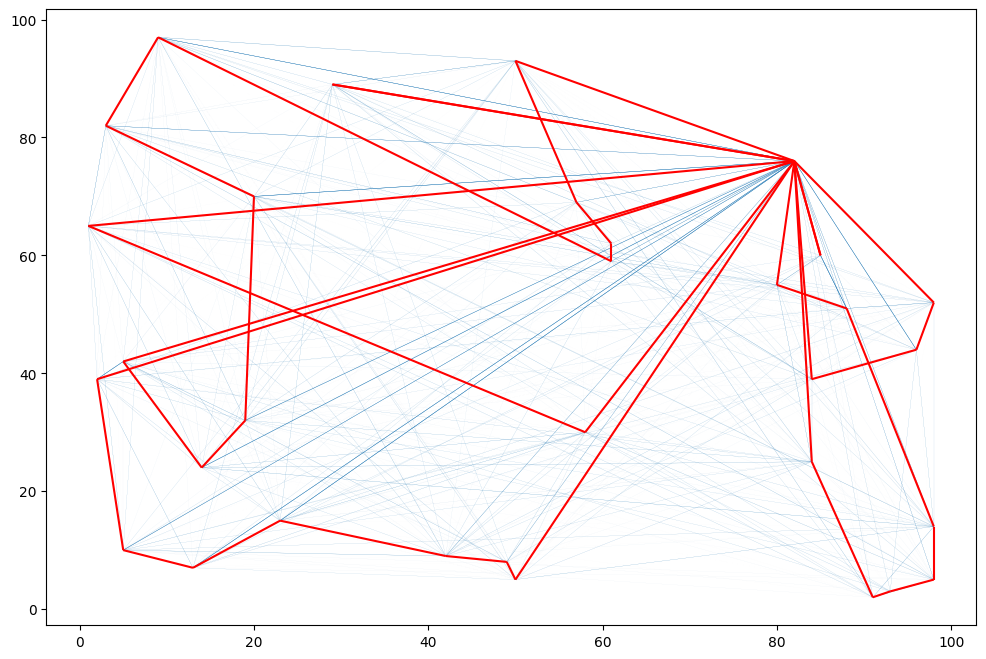

In [273]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import collections as mc

# plot the pheromone in blue, line width expresses the amount of pheromone on each edge
lines = []
colors = []
for i, v1 in enumerate(input_data["list_of_nodes"]):
    for j, v2 in enumerate(input_data["list_of_nodes"]):
        lines.append([(v1["x"], v1["y"]), (v2["x"], v2["y"])])
        colors.append(P[i][j])

lc = mc.LineCollection(lines, linewidths=np.array(colors))

plt.figure(figsize=(12, 8))
ax = plt.gca()
ax.add_collection(lc)
ax.autoscale()

best_sol = s # save the best solution (for the experiments below)

sol = best_sol

# we can test the effect of the parameters on the solution here
# sol = list(generate_solutions(vertices, P, distance, N=1, alpha=3, beta=1))[0]

# print the fitness of the solution
#print('Fitness: ', fitness(input_data["list_of_nodes"], distance, sol))

# print the order of the cities
print("sol_verts")
sol_verts = [input_data["list_of_nodes"] for i in sol]
import pprint
pprint.pprint(sol_verts)

# plot the solution in red
sol_lines = []
for i, j in zip(sol, sol[1:]):
    sol_lines.append([(input_data["list_of_nodes"][i]["x"], input_data["list_of_nodes"][i]["y"]), (input_data["list_of_nodes"][j]["x"], input_data["list_of_nodes"][j]["y"])])

sol_lines.append([(input_data["list_of_nodes"][sol[-1]]["x"], input_data["list_of_nodes"][sol[-1]]["y"]), (input_data["list_of_nodes"][sol[0]]["x"], input_data["list_of_nodes"][sol[0]]["y"])])

sols_lc = mc.LineCollection(sol_lines, colors='red')
ax.add_collection(sols_lc)